In [2]:
# Cell 1: 路径与参数
from pathlib import Path
fits_dir = Path(r"E:\NUS\galaxy\rc3\sdss_cutouts_hips2fits3")
out_npz  = Path(r"E:\NUS\galaxy\rc3\vectors_rotinv_all2.npz")

TARGET_SHAPE = (64, 64)   # A法输出尺寸 → 向量长度=4096
R_BINS       = 128        # B法径向分辨率 → 向量长度=2*R_BINS


In [5]:
# # Cell 1: 路径与参数
# from pathlib import Path
# fits_dir = Path(r"E:\NUS\galaxy\rc3\sdss_cutouts_hips2fits4")
# out_npz  = Path(r"E:\NUS\galaxy\rc3\vectors_rotinv_all3.npz")

# TARGET_SHAPE = (64, 64)   # A法输出尺寸 → 向量长度=4096
# R_BINS       = 128        # B法径向分辨率 → 向量长度=2*R_BINS


In [3]:
# Cell 2: 依赖 & 预处理（鲁棒版）
import numpy as np
from astropy.io import fits
from astropy.stats import SigmaClip, sigma_clipped_stats
from photutils.background import SExtractorBackground
from astropy.visualization import MinMaxInterval
from skimage.transform import rotate, resize, warp_polar
from skimage.measure import moments_central, inertia_tensor
from numpy.fft import fft2, fftshift

_interval   = MinMaxInterval()
_sigma_clip = SigmaClip(sigma=3.0, maxiters=5)
_bkg_est    = SExtractorBackground(sigma_clip=_sigma_clip)

def read_primary_fits(path):
    with fits.open(path, memmap=True) as hdul:
        for hdu in hdul:
            if getattr(hdu, "data", None) is not None and isinstance(hdu.data, np.ndarray) and hdu.data.ndim==2:
                return np.array(hdu.data, dtype=np.float32)
    raise ValueError(f"No 2D image in {path}")

def robust_preprocess(img, do_bg_sub=True, lo=0.5, hi=99.5, asinh_a=0.1):
    """
    - 背景：用 sigma-clipped 中位数扣除，避免过度扣除
    - 亮度：用分位数 lo-hi 做线性拉伸，再 asinh 压缩动态范围
    - 空图/近常数图：返回 None（外层跳过）
    """
    img = np.nan_to_num(img, nan=0.0, posinf=0.0, neginf=0.0)

    if do_bg_sub:
        mean, med, std = sigma_clipped_stats(img, sigma=3.0, maxiters=5)
        img = img - med

    span = float(img.max() - img.min())
    if not np.isfinite(span) or span < 1e-8:
        return None  # 近常数/空图

    vmin, vmax = np.percentile(img, [lo, hi])
    if not np.isfinite(vmin) or not np.isfinite(vmax) or vmax <= vmin + 1e-12:
        return None

    x = (img - vmin) / (vmax - vmin)
    x = np.clip(x, 0.0, 1.0)

    # asinh 压缩并归一化到 [0,1]
    x = np.arcsinh(x / max(asinh_a, 1e-6))
    x = (x - x.min()) / (x.max() - x.min() + 1e-12)

    return x.astype(np.float32)


In [4]:
# Cell 3: A法（对齐到主轴后统一尺寸 → 向量）
def principal_axis_angle(img):
    cy, cx = np.array(img.shape)/2.0
    mu = moments_central(img, center=(cy, cx), order=2)
    mu20, mu02, mu11 = mu[2,0], mu[0,2], mu[1,1]
    theta = 0.5 * np.arctan2(2.0*mu11, (mu20 - mu02 + 1e-12))
    return np.degrees(theta)

def canonicalize_orientation(img):
    ang = principal_axis_angle(img)
    imr = rotate(img, angle=-ang, order=1, preserve_range=True)
    # 统一上下（可选）：使上半更亮
    h = imr.shape[0]
    if imr[:h//2].sum() < imr[h//2:].sum():
        imr = np.flipud(imr)
    return imr.astype(np.float32)

# def vec_align_then_flat(path, target_shape=TARGET_SHAPE):
#     raw = read_primary_fits(path)
#     img = robust_preprocess(raw, do_bg_sub=True)
#     if img is None:
#         raise ValueError("flat/blank after preprocessing")
#     img = preprocess(read_primary_fits(path), do_bg_sub=True)
#     img = canonicalize_orientation(img)
#     img = resize(img, target_shape, order=1, anti_aliasing=True, preserve_range=True).astype(np.float32)
#     return img.ravel()
def vec_align_then_flat(path, target_shape=TARGET_SHAPE):
    raw = read_primary_fits(path)
    img = robust_preprocess(raw, do_bg_sub=True)
    if img is None:
        raise ValueError("flat/blank after preprocessing")
    # 下面保持你原来的对齐与 resize 流程
    ang = principal_axis_angle(img)
    imr = rotate(img, angle=-ang, order=1, preserve_range=True)
    h = imr.shape[0]
    if imr[:h//2].sum() < imr[h//2:].sum():
        imr = np.flipud(imr)
    imr = resize(imr, target_shape, order=1, anti_aliasing=True, preserve_range=True).astype(np.float32)
    return imr.ravel()



In [5]:
# Cell 4 — B法（I(r)+角向pk特征+半径向P(k)；角向同时用于double判别）
import numpy as np
from numpy.fft import fft2, fftshift
from skimage.transform import warp_polar
from scipy.signal import find_peaks

# === 可调超参 ===
ANG_M = 12            # 角向傅里叶特征维度：m=1..ANG_M
THETA_BINS = 360      # 角向分辨率（用于计算与判别，不直接入 XB）

def _moving_average_1d(x: np.ndarray, w: int) -> np.ndarray:
    if w <= 1: 
        return x.astype(float, copy=True)
    pad = w // 2
    x_pad = np.pad(x, (pad, pad), mode="reflect")
    ker = np.ones(w, dtype=float) / w
    y = np.convolve(x_pad, ker, mode="valid")
    # 强制回到原长
    if len(y) != len(x):
        xi = np.linspace(0,1,len(y)); xo = np.linspace(0,1,len(x))
        y = np.interp(xo, xi, y)
    return y.astype(np.float32)

def smooth_lr_windows35(lr_row: np.ndarray) -> np.ndarray:
    outs = [_moving_average_1d(lr_row, w) for w in (3,4,5)]
    return np.mean(np.stack(outs, axis=0), axis=0).astype(np.float32)

def _norm01(v: np.ndarray) -> np.ndarray:
    vmax, vmin = float(v.max()), float(v.min())
    if vmax > vmin:
        v = (v - vmin) / (vmax - vmin + 1e-12)
    else:
        v = np.zeros_like(v, dtype=np.float32)
    return v.astype(np.float32)

# --- I(r)
def radial_profile_from_polar(img, r_bins=R_BINS, theta_bins=THETA_BINS):
    h, w = img.shape
    m = min(h, w)
    y0, x0 = (h-m)//2, (w-m)//2
    img = img[y0:y0+m, x0:x0+m]
    polar = warp_polar(img, radius=m/2, output_shape=(int(r_bins), int(theta_bins)), scaling='linear')
    prof = polar.mean(axis=1)
    prof = _norm01(prof)
    if len(prof) != r_bins:
        raise ValueError(f"radial_profile length {len(prof)} != r_bins {r_bins}")
    return prof

# --- 频谱
def _fft_power_square(img_sq: np.ndarray) -> np.ndarray:
    F = fftshift(fft2(img_sq))
    return (np.abs(F)**2).astype(np.float32)

# --- P(k)（半径向；长度 R_BINS）
def radial_power_spectrum(img, r_bins=R_BINS):
    h, w = img.shape
    m = min(h, w)
    y0, x0 = (h-m)//2, (w-m)//2
    img_sq = img[y0:y0+m, x0:x0+m]

    ps = _fft_power_square(img_sq)
    H, W = ps.shape
    cy, cx = (H-1)/2.0, (W-1)/2.0
    yy, xx = np.indices(ps.shape)
    rr = np.hypot(yy - cy, xx - cx)
    edges = np.linspace(0, rr.max(), int(r_bins)+1)

    prof = np.zeros(int(r_bins), dtype=np.float32)
    for i in range(int(r_bins)):
        mask = (rr >= edges[i]) & (rr < edges[i+1])
        if np.any(mask):
            prof[i] = ps[mask].mean()
    prof = _norm01(np.log1p(prof))
    if len(prof) != r_bins:
        raise ValueError(f"radial_power length {len(prof)} != r_bins {r_bins}")
    return prof

# --- 角向 pk_theta(θ)（用于判别 + 提取特征）
def angular_power_profile(img, r_bins=R_BINS, theta_bins=THETA_BINS):
    h, w = img.shape
    m = min(h, w)
    y0, x0 = (h-m)//2, (w-m)//2
    img_sq = img[y0:y0+m, x0:x0+m]

    ps = _fft_power_square(img_sq)
    polar = warp_polar(ps, radius=ps.shape[0]/2, output_shape=(int(r_bins), int(theta_bins)), scaling='linear')
    theta_prof = polar.mean(axis=0)  # (theta_bins,)
    theta_prof = _norm01(np.log1p(theta_prof))
    if len(theta_prof) != theta_bins:
        raise ValueError(f"angular_profile length {len(theta_prof)} != theta_bins {theta_bins}")
    return theta_prof

def angular_fourier_feats(pk_theta, m_max=ANG_M):
    x = np.asarray(pk_theta, float)
    x = x - x.mean()
    spec = np.fft.rfft(x)
    mag = np.abs(spec)
    take = min(m_max, len(mag)-1)
    feats = np.zeros(m_max, dtype=np.float32)
    if take > 0:
        feats[:take] = np.log1p(mag[1:1+take]).astype(np.float32)
        if feats[:take].max() > 0:
            feats[:take] /= (feats[:take].max() + 1e-12)  # 归一
    return feats

# --- double 判别
def _double_score_from_theta(theta_profile: np.ndarray) -> float:
    x = np.asarray(theta_profile, dtype=float)
    x = x - x.mean()
    spec = np.fft.rfft(x)
    power = (spec.real**2 + spec.imag**2)
    if len(power) <= 3:
        return 0.0
    total = power[1:].sum() + 1e-12
    m2 = power[2] if len(power) > 2 else 0.0
    ratio_m2 = m2 / total
    W = max(3, int(round(len(x)*0.03)));  W += (1 - W % 2)
    xs = _moving_average_1d(x, W)
    peaks, _ = find_peaks(xs)
    if len(peaks) < 2:
        sep_score = 0.0
    else:
        top2 = peaks[np.argsort(xs[peaks])[-2:]]; top2.sort()
        n = len(xs)
        raw_sep = abs(top2[1] - top2[0]); alt_sep = n - raw_sep
        sep_bins = min(raw_sep, alt_sep)
        ideal = n/2.0
        sep_err = abs(sep_bins - ideal) / ideal
        sep_score = max(0.0, 1.0 - sep_err)
    score = (ratio_m2**0.5) * (sep_score**0.5)
    return float(np.clip(score, 0.0, 1.0))

def is_double_from_pk_theta(pk_theta: np.ndarray, thresh: float = 0.45) -> bool:
    return _double_score_from_theta(pk_theta) >= thresh

# --- 半径向高通（长度不变：低频置零）
def highpass_inplace(pk_r: np.ndarray, keep_high_frac: float = 0.8, kmin: int = None) -> np.ndarray:
    pk = pk_r.astype(np.float32, copy=True)
    K = len(pk)
    if kmin is not None:
        k0 = max(0, min(int(kmin), K-1))
    else:
        K_keep = max(1, int(round(K * float(keep_high_frac))))
        k0 = K - K_keep
    if k0 > 0:
        pk[:k0] = 0.0
    pk = _norm01(pk)
    return pk

# --- 主函数：XB = [ I(r)_smooth | ANG_FOURIER(m=1..M) | high-pass P(k) ]
def vec_rot_invariant(path, r_bins=R_BINS, theta_bins=THETA_BINS,
                      double_thresh=0.45, keep_high_frac=0.8, kmin=None, ang_m=ANG_M):
    raw = read_primary_fits(path)
    img = robust_preprocess(raw, do_bg_sub=True)
    if img is None:
        raise ValueError("flat/blank after preprocessing")

    # 裁方形
    h, w = img.shape
    m = min(h, w)
    y0, x0 = (h-m)//2, (w-m)//2
    img_sq = img[y0:y0+m, x0:x0+m]

    # I(r) + 平滑（R_BINS）
    lr = radial_profile_from_polar(img_sq, r_bins=int(r_bins), theta_bins=int(theta_bins))
    lr_s = smooth_lr_windows35(lr)

    # 角向 pk：判别 + 特征（ANG_M）
    pk_theta = angular_power_profile(img_sq, r_bins=int(r_bins), theta_bins=int(theta_bins))
    if is_double_from_pk_theta(pk_theta, thresh=double_thresh):
        raise ValueError("double galaxy detected")
    ang_feats = angular_fourier_feats(pk_theta, m_max=int(ang_m))

    # 半径向 pk（R_BINS）+ 高通
    pk_r = radial_power_spectrum(img_sq, r_bins=int(r_bins))
    pk_r_hp = highpass_inplace(pk_r, keep_high_frac=keep_high_frac, kmin=kmin)

    xb = np.concatenate([lr_s.astype(np.float32), ang_feats.astype(np.float32), pk_r_hp.astype(np.float32)], axis=0)
    expected = int(r_bins) + int(ang_m) + int(r_bins)
    if xb.shape[0] != expected:
        raise ValueError(f"XB length {xb.shape[0]} != expected {expected}")
    return xb


In [6]:
# # Cell 5: 扫描整个目录（含子文件夹），批量向量化并保存
# fits_paths = sorted(p for p in fits_dir.rglob("*.fits") if p.is_file())

# XA, XB, names = [], [], []
# for p in fits_paths:
#     try:
#         vA = vec_align_then_flat(p)       # 64x64 → 4096
#         vB = vec_rot_invariant(p)         # 2*R_BINS
#         # 保护：若还是零向量/近常数，就跳过
#         if (np.allclose(vA, 0) and np.allclose(vB, 0)) or (
#             (vA.max() - vA.min()) < 1e-6 and (vB.max() - vB.min()) < 1e-6
#         ):
#             raise ValueError("all-zero/near-constant vector")
#         XA.append(vA); XB.append(vB); names.append(str(p.relative_to(fits_dir)))
#     except Exception as e:
#         print(f"[SKIP] {p}: {e}")

# XA = np.vstack(XA) if XA else np.zeros((0, TARGET_SHAPE[0]*TARGET_SHAPE[1]), np.float32)
# XB = np.vstack(XB) if XB else np.zeros((0, 2*R_BINS), np.float32)


# np.savez_compressed(out_npz,
#                     XA=XA, XB=XB,
#                     names=np.array(names),
#                     meta=np.array([f"TARGET_SHAPE={TARGET_SHAPE}",
#                                    f"R_BINS={R_BINS}",
#                                    "A=align-then-flat (rotation canonicalization)",
#                                    "B=radial intensity + radial power spectrum (strictly rotation-invariant)"]))
# print(f"[DONE] {out_npz}\nXA={XA.shape}  XB={XB.shape}  N={len(names)}")


In [7]:
# Cell 5 — 扫描→向量化→保存（适配新的 XB 维度）
import traceback

fits_paths = sorted(p for p in fits_dir.rglob("*.fits") if p.is_file())

XA, XB, names = [], [], []
for p in fits_paths:
    try:
        vA = vec_align_then_flat(p)             # 64x64 → 4096
        vB = vec_rot_invariant(p, ang_m=ANG_M)  # R_BINS + ANG_M + R_BINS
        # 保护：若还是零向量/近常数，就跳过
        if (np.allclose(vA, 0) and np.allclose(vB, 0)) or (
            (vA.max() - vA.min()) < 1e-6 and (vB.max() - vB.min()) < 1e-6
        ):
            raise ValueError("all-zero/near-constant vector")
        # 形状检查
        if vA.shape != (TARGET_SHAPE[0]*TARGET_SHAPE[1],):
            raise ValueError(f"vA shape wrong: {vA.shape}")
        if vB.shape[0] != (R_BINS + ANG_M + R_BINS):
            raise ValueError(f"vB length wrong: {vB.shape[0]} vs {R_BINS + ANG_M + R_BINS}")
        XA.append(vA); XB.append(vB); names.append(str(p.relative_to(fits_dir)))
    except Exception as e:
        print(f"[SKIP] {p}: {e}")
        tb = traceback.format_exc(limit=2)
        print("[TRACE]", tb.strip())

XA = np.vstack(XA) if XA else np.zeros((0, TARGET_SHAPE[0]*TARGET_SHAPE[1]), np.float32)
XB = np.vstack(XB) if XB else np.zeros((0, R_BINS + ANG_M + R_BINS), np.float32)

np.savez_compressed(out_npz,
                    XA=XA, XB=XB,
                    names=np.array(names),
                    meta=np.array([f"TARGET_SHAPE={TARGET_SHAPE}",
                                   f"R_BINS={R_BINS}",
                                   f"ANG_M={ANG_M}",
                                   f"THETA_BINS={THETA_BINS}",
                                   "B = [ smoothed I(r) | angular Fourier m=1..ANG_M | high-pass radial P(k) ]",
                                   "A = align-then-flat (rotation canonicalization)"]))
print(f"[DONE] {out_npz}\nXA={XA.shape}  XB={XB.shape}  N={len(names)}")


[SKIP] E:\NUS\galaxy\rc3\sdss_cutouts_hips2fits3\g\ESO__111-_12_103_g.fits: flat/blank after preprocessing
[TRACE] Traceback (most recent call last):
  File "c:\temp\temp\ipykernel_3836\2517647457.py", line 9, in <module>
    vA = vec_align_then_flat(p)             # 64x64 → 4096
  File "c:\temp\temp\ipykernel_3836\1219484836.py", line 31, in vec_align_then_flat
    raise ValueError("flat/blank after preprocessing")
ValueError: flat/blank after preprocessing
[SKIP] E:\NUS\galaxy\rc3\sdss_cutouts_hips2fits3\g\ESO__149-_12_26_g.fits: flat/blank after preprocessing
[TRACE] Traceback (most recent call last):
  File "c:\temp\temp\ipykernel_3836\2517647457.py", line 9, in <module>
    vA = vec_align_then_flat(p)             # 64x64 → 4096
  File "c:\temp\temp\ipykernel_3836\1219484836.py", line 31, in vec_align_then_flat
    raise ValueError("flat/blank after preprocessing")
ValueError: flat/blank after preprocessing
[SKIP] E:\NUS\galaxy\rc3\sdss_cutouts_hips2fits3\g\ESO__149-_13_57_g.fits: 

[SKIP] E:\NUS\galaxy\rc3\sdss_cutouts_hips2fits3\g\MCG_-2-_1-_19_114_g.fits: flat/blank after preprocessing
[TRACE] Traceback (most recent call last):
  File "c:\temp\temp\ipykernel_3836\2517647457.py", line 9, in <module>
    vA = vec_align_then_flat(p)             # 64x64 → 4096
  File "c:\temp\temp\ipykernel_3836\1219484836.py", line 31, in vec_align_then_flat
    raise ValueError("flat/blank after preprocessing")
ValueError: flat/blank after preprocessing
[SKIP] E:\NUS\galaxy\rc3\sdss_cutouts_hips2fits3\g\MCG_-2-_1-_22_126_g.fits: flat/blank after preprocessing
[TRACE] Traceback (most recent call last):
  File "c:\temp\temp\ipykernel_3836\2517647457.py", line 9, in <module>
    vA = vec_align_then_flat(p)             # 64x64 → 4096
  File "c:\temp\temp\ipykernel_3836\1219484836.py", line 31, in vec_align_then_flat
    raise ValueError("flat/blank after preprocessing")
ValueError: flat/blank after preprocessing
[SKIP] E:\NUS\galaxy\rc3\sdss_cutouts_hips2fits3\g\MCG_-2-_1-_25A_144_g.

[SKIP] E:\NUS\galaxy\rc3\sdss_cutouts_hips2fits3\i\ESO__111-_12_103_i.fits: flat/blank after preprocessing
[TRACE] Traceback (most recent call last):
  File "c:\temp\temp\ipykernel_3836\2517647457.py", line 9, in <module>
    vA = vec_align_then_flat(p)             # 64x64 → 4096
  File "c:\temp\temp\ipykernel_3836\1219484836.py", line 31, in vec_align_then_flat
    raise ValueError("flat/blank after preprocessing")
ValueError: flat/blank after preprocessing
[SKIP] E:\NUS\galaxy\rc3\sdss_cutouts_hips2fits3\i\ESO__149-_12_26_i.fits: flat/blank after preprocessing
[TRACE] Traceback (most recent call last):
  File "c:\temp\temp\ipykernel_3836\2517647457.py", line 9, in <module>
    vA = vec_align_then_flat(p)             # 64x64 → 4096
  File "c:\temp\temp\ipykernel_3836\1219484836.py", line 31, in vec_align_then_flat
    raise ValueError("flat/blank after preprocessing")
ValueError: flat/blank after preprocessing
[SKIP] E:\NUS\galaxy\rc3\sdss_cutouts_hips2fits3\i\ESO__149-_13_57_i.fits: 

[SKIP] E:\NUS\galaxy\rc3\sdss_cutouts_hips2fits3\i\MCG_-2-_1-_19_114_i.fits: flat/blank after preprocessing
[TRACE] Traceback (most recent call last):
  File "c:\temp\temp\ipykernel_3836\2517647457.py", line 9, in <module>
    vA = vec_align_then_flat(p)             # 64x64 → 4096
  File "c:\temp\temp\ipykernel_3836\1219484836.py", line 31, in vec_align_then_flat
    raise ValueError("flat/blank after preprocessing")
ValueError: flat/blank after preprocessing
[SKIP] E:\NUS\galaxy\rc3\sdss_cutouts_hips2fits3\i\MCG_-2-_1-_22_126_i.fits: flat/blank after preprocessing
[TRACE] Traceback (most recent call last):
  File "c:\temp\temp\ipykernel_3836\2517647457.py", line 9, in <module>
    vA = vec_align_then_flat(p)             # 64x64 → 4096
  File "c:\temp\temp\ipykernel_3836\1219484836.py", line 31, in vec_align_then_flat
    raise ValueError("flat/blank after preprocessing")
ValueError: flat/blank after preprocessing
[SKIP] E:\NUS\galaxy\rc3\sdss_cutouts_hips2fits3\i\MCG_-2-_1-_25A_144_i.

[SKIP] E:\NUS\galaxy\rc3\sdss_cutouts_hips2fits3\i\UGC_12918_46_i.fits: double galaxy detected
[TRACE] Traceback (most recent call last):
  File "c:\temp\temp\ipykernel_3836\2517647457.py", line 10, in <module>
    vB = vec_rot_invariant(p, ang_m=ANG_M)  # R_BINS + ANG_M + R_BINS
  File "c:\temp\temp\ipykernel_3836\1016094069.py", line 171, in vec_rot_invariant
    raise ValueError("double galaxy detected")
ValueError: double galaxy detected
[SKIP] E:\NUS\galaxy\rc3\sdss_cutouts_hips2fits3\i\UGC____39_123_i.fits: flat/blank after preprocessing
[TRACE] Traceback (most recent call last):
  File "c:\temp\temp\ipykernel_3836\2517647457.py", line 9, in <module>
    vA = vec_align_then_flat(p)             # 64x64 → 4096
  File "c:\temp\temp\ipykernel_3836\1219484836.py", line 31, in vec_align_then_flat
    raise ValueError("flat/blank after preprocessing")
ValueError: flat/blank after preprocessing
[SKIP] E:\NUS\galaxy\rc3\sdss_cutouts_hips2fits3\i\UGC____45_135_i.fits: flat/blank after prep

...

[SKIP] E:\NUS\galaxy\rc3\sdss_cutouts_hips2fits3\u\ESO__111-_12_103_u.fits: flat/blank after preprocessing
[TRACE] Traceback (most recent call last):
  File "c:\temp\temp\ipykernel_3836\2517647457.py", line 9, in <module>
    vA = vec_align_then_flat(p)             # 64x64 → 4096
  File "c:\temp\temp\ipykernel_3836\1219484836.py", line 31, in vec_align_then_flat
    raise ValueError("flat/blank after preprocessing")
ValueError: flat/blank after preprocessing
[SKIP] E:\NUS\galaxy\rc3\sdss_cutouts_hips2fits3\u\ESO__149-_12_26_u.fits: flat/blank after preprocessing
[TRACE] Traceback (most recent call last):
  File "c:\temp\temp\ipykernel_3836\2517647457.py", line 9, in <module>
    vA = vec_align_then_flat(p)             # 64x64 → 4096
  File "c:\temp\temp\ipykernel_3836\1219484836.py", line 31, in vec_align_then_flat
    raise ValueError("flat/blank after preprocessing")
ValueError: flat/blank after preprocessing
[SKIP] E:\NUS\galaxy\rc3\sdss_cutouts_hips2fits3\u\ESO__149-_13_57_u.fits: 

[SKIP] E:\NUS\galaxy\rc3\sdss_cutouts_hips2fits3\u\MCG_-2-_1-_19_114_u.fits: flat/blank after preprocessing
[TRACE] Traceback (most recent call last):
  File "c:\temp\temp\ipykernel_3836\2517647457.py", line 9, in <module>
    vA = vec_align_then_flat(p)             # 64x64 → 4096
  File "c:\temp\temp\ipykernel_3836\1219484836.py", line 31, in vec_align_then_flat
    raise ValueError("flat/blank after preprocessing")
ValueError: flat/blank after preprocessing
[SKIP] E:\NUS\galaxy\rc3\sdss_cutouts_hips2fits3\u\MCG_-2-_1-_22_126_u.fits: flat/blank after preprocessing
[TRACE] Traceback (most recent call last):
  File "c:\temp\temp\ipykernel_3836\2517647457.py", line 9, in <module>
    vA = vec_align_then_flat(p)             # 64x64 → 4096
  File "c:\temp\temp\ipykernel_3836\1219484836.py", line 31, in vec_align_then_flat
    raise ValueError("flat/blank after preprocessing")
ValueError: flat/blank after preprocessing
[SKIP] E:\NUS\galaxy\rc3\sdss_cutouts_hips2fits3\u\MCG_-2-_1-_25A_144_u.

[SKIP] E:\NUS\galaxy\rc3\sdss_cutouts_hips2fits3\z\ESO__111-_12_103_z.fits: flat/blank after preprocessing
[TRACE] Traceback (most recent call last):
  File "c:\temp\temp\ipykernel_3836\2517647457.py", line 9, in <module>
    vA = vec_align_then_flat(p)             # 64x64 → 4096
  File "c:\temp\temp\ipykernel_3836\1219484836.py", line 31, in vec_align_then_flat
    raise ValueError("flat/blank after preprocessing")
ValueError: flat/blank after preprocessing
[SKIP] E:\NUS\galaxy\rc3\sdss_cutouts_hips2fits3\z\ESO__149-_12_26_z.fits: flat/blank after preprocessing
[TRACE] Traceback (most recent call last):
  File "c:\temp\temp\ipykernel_3836\2517647457.py", line 9, in <module>
    vA = vec_align_then_flat(p)             # 64x64 → 4096
  File "c:\temp\temp\ipykernel_3836\1219484836.py", line 31, in vec_align_then_flat
    raise ValueError("flat/blank after preprocessing")
ValueError: flat/blank after preprocessing
[SKIP] E:\NUS\galaxy\rc3\sdss_cutouts_hips2fits3\z\ESO__149-_13_57_z.fits: 

[SKIP] E:\NUS\galaxy\rc3\sdss_cutouts_hips2fits3\z\MCG_-2-_1-_19_114_z.fits: flat/blank after preprocessing
[TRACE] Traceback (most recent call last):
  File "c:\temp\temp\ipykernel_3836\2517647457.py", line 9, in <module>
    vA = vec_align_then_flat(p)             # 64x64 → 4096
  File "c:\temp\temp\ipykernel_3836\1219484836.py", line 31, in vec_align_then_flat
    raise ValueError("flat/blank after preprocessing")
ValueError: flat/blank after preprocessing
[SKIP] E:\NUS\galaxy\rc3\sdss_cutouts_hips2fits3\z\MCG_-2-_1-_22_126_z.fits: flat/blank after preprocessing
[TRACE] Traceback (most recent call last):
  File "c:\temp\temp\ipykernel_3836\2517647457.py", line 9, in <module>
    vA = vec_align_then_flat(p)             # 64x64 → 4096
  File "c:\temp\temp\ipykernel_3836\1219484836.py", line 31, in vec_align_then_flat
    raise ValueError("flat/blank after preprocessing")
ValueError: flat/blank after preprocessing
[SKIP] E:\NUS\galaxy\rc3\sdss_cutouts_hips2fits3\z\MCG_-2-_1-_25A_144_z.

[DONE] E:\NUS\galaxy\rc3\vectors_rotinv_all2.npz
XA=(478, 4096)  XB=(478, 268)  N=478


In [8]:
def visualize_xb_auto(xb_row, r_bins, ang_m_meta=None, title=None, show_grid=True):
    """
    自适应可视化：
      - 若 len == 2*r_bins: 视为 [I(r) | P(k)] -> 双联图
      - 若 len >  2*r_bins: 视为 [I(r) | ANG(=len-2*r_bins) | P(k)] -> 三联图
    """
    import numpy as np, matplotlib.pyplot as plt
    xb_row = np.asarray(xb_row).astype(float)
    L = xb_row.size
    twoR = 2 * int(r_bins)

    if L < twoR:
        raise ValueError(f"XB length {L} < 2*R_BINS ({twoR}) — 数据异常")
    has_ang = (L > twoR)
    ang_m = (L - twoR) if has_ang else 0

    # 如果 meta 里有 ANG_M，但与推断不一致，仅提示，不中断
    if ang_m_meta is not None and has_ang and ang_m_meta != ang_m:
        print(f"[warn] ANG_M in meta={ang_m_meta}, inferred={ang_m}; 使用 inferred={ang_m}")

    lr  = xb_row[:r_bins]
    if has_ang:
        ang = xb_row[r_bins:r_bins+ang_m]
        pk  = xb_row[r_bins+ang_m:]
    else:
        ang = None
        pk  = xb_row[r_bins:]

    if has_ang:
        fig = plt.figure(figsize=(12,3.2))
        ax1 = plt.subplot(1,3,1)
        ax2 = plt.subplot(1,3,2)
        ax3 = plt.subplot(1,3,3)
    else:
        fig = plt.figure(figsize=(9,3.2))
        ax1 = plt.subplot(1,2,1)
        ax3 = plt.subplot(1,2,2)
        ax2 = None  # 没有角向

    # I(r)
    ax1.plot(np.arange(r_bins), lr, lw=1.8)
    ax1.set_title("smoothed I(r)")
    ax1.set_xlabel("radius bin"); ax1.set_ylabel("normalized intensity")
    if show_grid: ax1.grid(alpha=0.3)

    # ANG（如有）
    if has_ang:
        ax2.stem(np.arange(1, ang_m+1), ang, use_line_collection=True)
        ax2.set_title(f"angular Fourier |m| (m=1..{ang_m})")
        ax2.set_xlabel("m"); ax2.set_ylabel("normalized amplitude")
        if show_grid: ax2.grid(alpha=0.3)

    # P(k)
    ax3.plot(np.arange(r_bins), pk, lw=1.8)
    ax3.set_title("high-pass radial P(k)")
    ax3.set_xlabel("radial frequency bin (k)"); ax3.set_ylabel("normalized power")
    if show_grid: ax3.grid(alpha=0.3)

    if title: fig.suptitle(title, y=1.05, fontsize=12)
    plt.tight_layout(); plt.show()


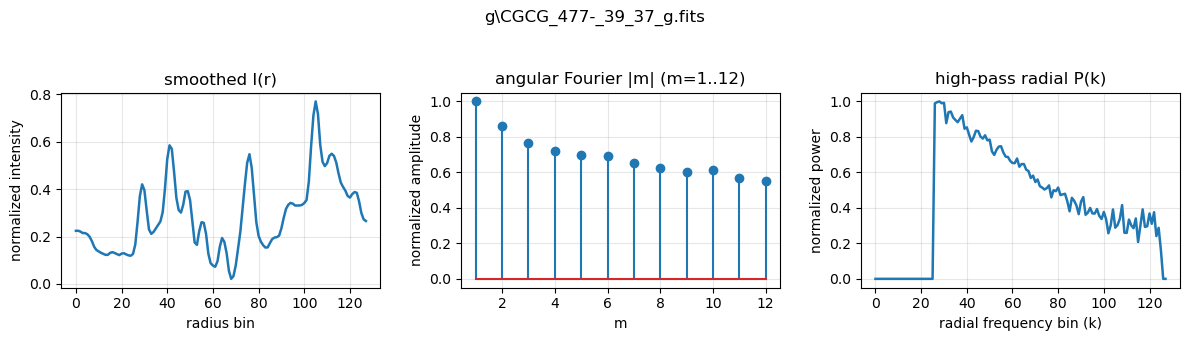

In [9]:
i = 0
ttl = str(names[i]) if names is not None and len(names)>i else f"index {i}"
visualize_xb_auto(XB[i], R_BINS, ang_m_meta=ANG_M, title=ttl)


In [19]:
# === One-Cell: Robust RC3 read + 5-band vectorization (u,g,r,i,z) ===
import os, re, io, numpy as np, pandas as pd
from astropy.io import fits
from astropy.coordinates import Angle

# ---------- paths (edit if needed) ----------
rc3_tsv     = r"E:\NUS\galaxy\rc3\asu2.tsv"
outdir      = r"E:\NUS\galaxy\rc3\sdss_cutouts_hips2fits2"
report_csv  = r"E:\NUS\galaxy\rc3\centered_check_report2.csv"
out_npz     = os.path.join(outdir, "vectors_ugriz_flat.npz")

# ---------- params ----------
BANDS_ORDER        = ['u','g','r','i','z']
TARGET_H, TARGET_W = 64, 64
Z_SCORE_PER_BAND   = True
USE_REPORT_FILTER  = True

# ---------- helpers: robust reading ----------
def detect_sep(path, max_lines=200):
    counts = {';':0, '\t':0, ',':0}
    with open(path, 'r', encoding='utf-8', errors='ignore') as f:
        used = 0
        for line in f:
            if used >= max_lines: break
            s = line.strip()
            if not s or s.startswith('#'): continue
            for k in counts: counts[k] += s.count(k)
            used += 1
    # pick the sep with max total counts
    sep = max(counts, key=counts.get)
    return sep if counts[sep] > 0 else None

def read_rc3_robust(path):
    # try detected sep -> fallback list
    tries = []
    sep = detect_sep(path)
    cand_list = ([sep] if sep else []) + [';', '\t', ',', r'\s+']
    used_sep = None
    last_err = None
    for c in cand_list:
        try:
            if c == r'\s+':
                df = pd.read_csv(path, sep=c, engine='python', comment='#')
                used_sep = 'whitespace'
            else:
                df = pd.read_csv(path, sep=c, engine='python', comment='#')
                used_sep = c
            if df.shape[1] == 1:
                # single-column -> likely wrong sep; continue trying
                tries.append((c, 'one-column'))
                continue
            df.columns = [str(x).strip() for x in df.columns]
            return df.reset_index(drop=True), used_sep, tries
        except Exception as e:
            last_err = str(e)
            tries.append((c, f'err={last_err}'))
    raise RuntimeError(f"无法解析 RC3 表。尝试：{tries}")

# ---------- read RC3 ----------
rc3, used_sep, tries = read_rc3_robust(rc3_tsv)
print(f"[INFO] RC3 loaded: shape={rc3.shape}, sep='{used_sep}'")
print(f"[DEBUG] tries: {tries[:3]}")
print("[INFO] columns (sample):", rc3.columns[:12].tolist())

# ---------- column mapping ----------
def _pick_col_ci(df, candidates):
    lower2orig = {c.lower(): c for c in df.columns}
    for c in candidates:
        if c.lower() in lower2orig:
            return lower2orig[c.lower()]
    raise KeyError(f"未找到列（候选：{candidates}）；现有列示例：{list(df.columns)[:12]}")

RA_COL  = _pick_col_ci(rc3, ["_RAJ2000","RA_ICRS","RAJ2000","RA2000","RA"])
DEC_COL = _pick_col_ci(rc3, ["_DEJ2000","DE_ICRS","DEJ2000","DE2000","DEC","Dec"])

NAME_COL = None
for c in ["altname","Name","name","objname","ObjName","ID","id","PGC","NGC","UGC","IC","Messier"]:
    try:
        NAME_COL = _pick_col_ci(rc3, [c]); break
    except KeyError:
        continue

def sanitize(s: str) -> str:
    s = re.sub(r"\s+", "_", str(s).strip())
    s = re.sub(r"[^\w\-+.=]", "", s)
    return s or "UNK"

def get_base_name(idx:int):
    if NAME_COL is not None:
        v = rc3.loc[idx, NAME_COL]
        if pd.notna(v) and str(v).strip().lower() != "nan":
            return sanitize(v)
    for c in ["PGC","NGC","UGC","IC","Messier"]:
        try:
            col = _pick_col_ci(rc3, [c])
            v = rc3.loc[idx, col]
            if pd.notna(v) and str(v).strip().lower() != "nan":
                return sanitize(f"{c}_{v}")
        except KeyError:
            pass
    return f"RC3_{idx}"

def to_float_ra(x):
    try:
        return float(x)
    except Exception:
        try:
            return Angle(str(x), unit='hourangle').degree
        except Exception:
            return Angle(str(x), unit='degree').degree

def to_float_dec(x):
    try:
        return float(x)
    except Exception:
        return Angle(str(x), unit='degree').degree

def get_ra_dec(idx:int):
    return to_float_ra(rc3.loc[idx, RA_COL]), to_float_dec(rc3.loc[idx, DEC_COL])

print(f"[OK] Mapped columns: RA={RA_COL}, DEC={DEC_COL}, NAME={NAME_COL}")

# ---------- optional: filter by report ----------
ok_by_idx = {}
if USE_REPORT_FILTER and os.path.exists(report_csv) and os.path.getsize(report_csv) > 0:
    try:
        rep = pd.read_csv(report_csv)
        if 'idx' in rep.columns:
            for idx, grp in rep.groupby('idx'):
                g_ok = grp.query("status == 'OK'") if 'status' in grp.columns else grp
                all_invalid = ('maybe_no_coverage' in g_ok.columns) and g_ok['maybe_no_coverage'].fillna(False).all()
                ok_by_idx[int(idx)] = (len(g_ok) > 0) and (not all_invalid)
        print(f"[INFO] report loaded, usable idx count: {sum(ok_by_idx.values())}")
    except Exception as e:
        print("[WARN] 读取 report 失败，忽略过滤：", e)

# ---------- index FITS (idx, band) ----------
pat = re.compile(r"_(\d+)_([ugriz])\.fits$", flags=re.I)
index_map = {}  # (idx:int, band:str) -> path
total_files = 0
for root, _, files in os.walk(outdir):
    for f in files:
        if not f.lower().endswith(".fits"): continue
        total_files += 1
        m = pat.search(f.lower())
        if not m: continue
        idx = int(m.group(1)); band = m.group(2).lower()
        p = os.path.join(root, f)
        prev = index_map.get((idx, band))
        if prev is None or (os.sep + band + os.sep) in p.lower():
            index_map[(idx, band)] = p

print(f"[INFO] scanned FITS: total={total_files}, indexed={len(index_map)} pairs")

# ---------- read & clean FITS ----------
def load_clean_fits(path):
    try:
        with fits.open(path) as hdul:
            hdu = next((h for h in hdul if getattr(h, "data", None) is not None), None)
            if hdu is None: return None
            arr = np.asarray(hdu.data)
    except Exception:
        return None
    if arr.ndim > 2: arr = arr.reshape(arr.shape[-2], arr.shape[-1])
    if arr.shape != (TARGET_H, TARGET_W): return None
    arr = arr.astype(np.float32, copy=False)
    mask_finite = np.isfinite(arr)
    if not mask_finite.any(): return None
    arr[~mask_finite] = 0.0
    return arr

# ---------- main loop ----------
vectors, names, indices, missing_mask = [], [], [], []
N = len(rc3)
for idx in range(N):
    if ok_by_idx and (idx in ok_by_idx) and (not ok_by_idx[idx]):
        continue
    altname = get_base_name(idx)

    band_arrays, band_missing = [], []
    for b in BANDS_ORDER:
        p = index_map.get((idx, b))
        if p is None or (not os.path.exists(p)):
            band_arrays.append(np.zeros((TARGET_H, TARGET_W), dtype=np.float32))
            band_missing.append(True)
            continue
        a = load_clean_fits(p)
        if a is None:
            band_arrays.append(np.zeros((TARGET_H, TARGET_W), dtype=np.float32))
            band_missing.append(True)
        else:
            band_arrays.append(a); band_missing.append(False)

    if Z_SCORE_PER_BAND:
        tmp = []
        for a in band_arrays:
            mu, sigma = float(a.mean()), float(a.std())
            tmp.append((a - mu) / sigma if sigma > 0 else a*0.0)
        band_arrays = tmp

    vec = np.concatenate([a.ravel() for a in band_arrays], axis=0)  # 5*64*64=20480
    vectors.append(vec)
    names.append(f"{altname}_{idx}")
    indices.append(idx)
    missing_mask.append(band_missing)

X = np.vstack(vectors) if vectors else np.zeros((0, len(BANDS_ORDER)*TARGET_H*TARGET_W), dtype=np.float32)
names = np.array(names, dtype=object)
indices = np.array(indices, dtype=np.int32)
mask_missing = np.array(missing_mask, dtype=bool)

# ---------- save ----------
np.savez_compressed(
    out_npz,
    X=X,
    names=names,
    indices=indices,
    mask_missing=mask_missing,
    band_order=np.array(BANDS_ORDER),
    H=np.int32(TARGET_H),
    W=np.int32(TARGET_W),
)
print(f"[DONE] vectors saved -> {out_npz}")
print(f"[SHAPE] X={X.shape}, missing-any-band={mask_missing.any(axis=1).sum()} / {len(mask_missing)}")


[INFO] RC3 loaded: shape=(10001, 13), sep=';'
[DEBUG] tries: []
[INFO] columns (sample): ['_RAJ2000', '_DEJ2000', 'RA2000', 'DE2000', 'altname', 'PGC', 'type', 'T', 'D25', 'R25', 'BT', 'BT_code']
[OK] Mapped columns: RA=_RAJ2000, DEC=_DEJ2000, NAME=altname
[INFO] report loaded, usable idx count: 96
[INFO] scanned FITS: total=167, indexed=0 pairs
[DONE] vectors saved -> E:\NUS\galaxy\rc3\sdss_cutouts_hips2fits2\vectors_ugriz_flat.npz
[SHAPE] X=(9947, 20480), missing-any-band=9947 / 9947
